# ECG Arrhythmia Classifier

Full pipeline from raw MIT-BIH ECG signals to arrhythmia classification.

**Sections:**
1. Imports and setup
2. Preprocessing (baseline wander, notch, low-pass)
3. Pan-Tompkins R-peak detection
4. Beat segmentation and AAMI label mapping
5. Feature extraction (RR intervals + wavelets)
6. Classification and cross-validation

**To run:** Restart kernel and run all cells in order. Requires MIT-BIH data at `data/mitdb/` — see README for download instructions.

In [2]:
import os

import numpy as np

# Set explicitly to project root regardless of where kernel started
os.chdir(r'C:\Users\nicho\Documents\Personal Projects\Portfolio\ecg-arrhythmia-classifier')
print(os.getcwd())

C:\Users\nicho\Documents\Personal Projects\Portfolio\ecg-arrhythmia-classifier


In [3]:
# ONLY RUN ONCE — data already downloaded
import wfdb
try:
    # wfdb.dl_database('mitdb', dl_dir='data/mitdb')
    print("done")
except Exception as e:
    print(f"Error: {e}")

done


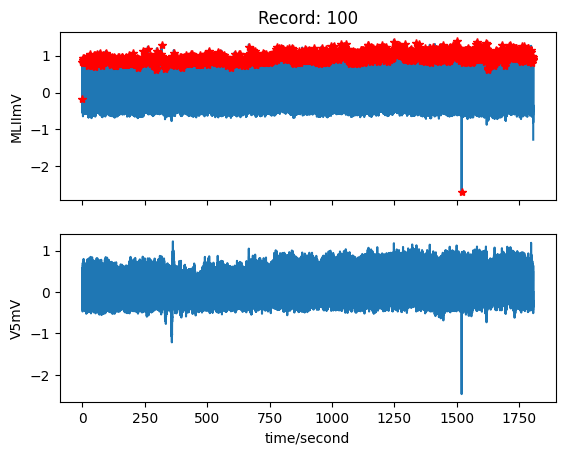

In [4]:
import wfdb

record = wfdb.rdrecord('data/mitdb/100')
annotation = wfdb.rdann('data/mitdb/100', 'atr')
wfdb.plot_wfdb(record=record, annotation=annotation, time_units='seconds')

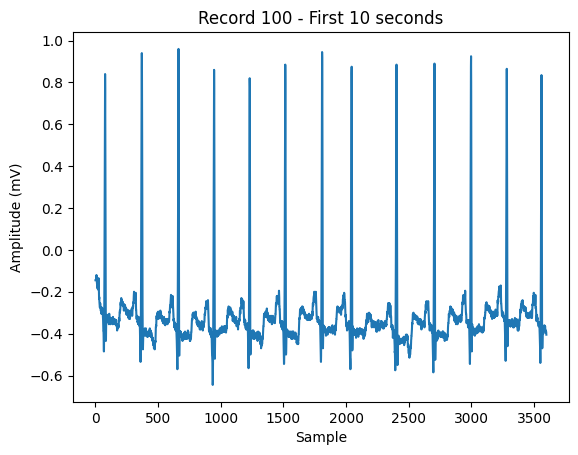

In [5]:
import wfdb
import matplotlib.pyplot as plt

record = wfdb.rdrecord('data/mitdb/100')
signal = record.p_signal[:, 0]  # channel 0
fs = record.fs  # sampling frequency (360 Hz)

# plot first 10 seconds
plt.plot(signal[:10*fs])
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.title('Record 100 - First 10 seconds')
plt.show()

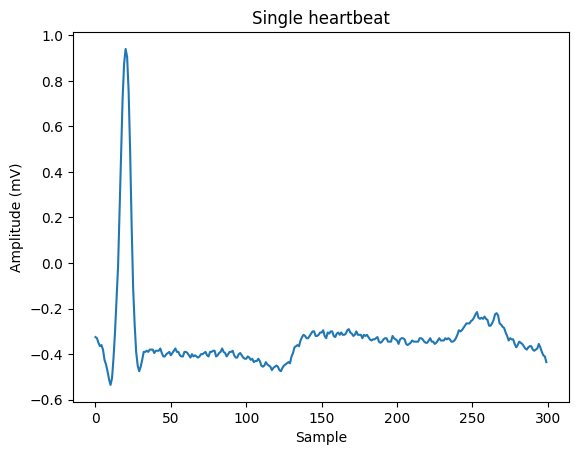

In [6]:
# zoom into one beat -- samples 350 to 650
plt.plot(signal[350:650])
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.title('Single heartbeat')
plt.show()

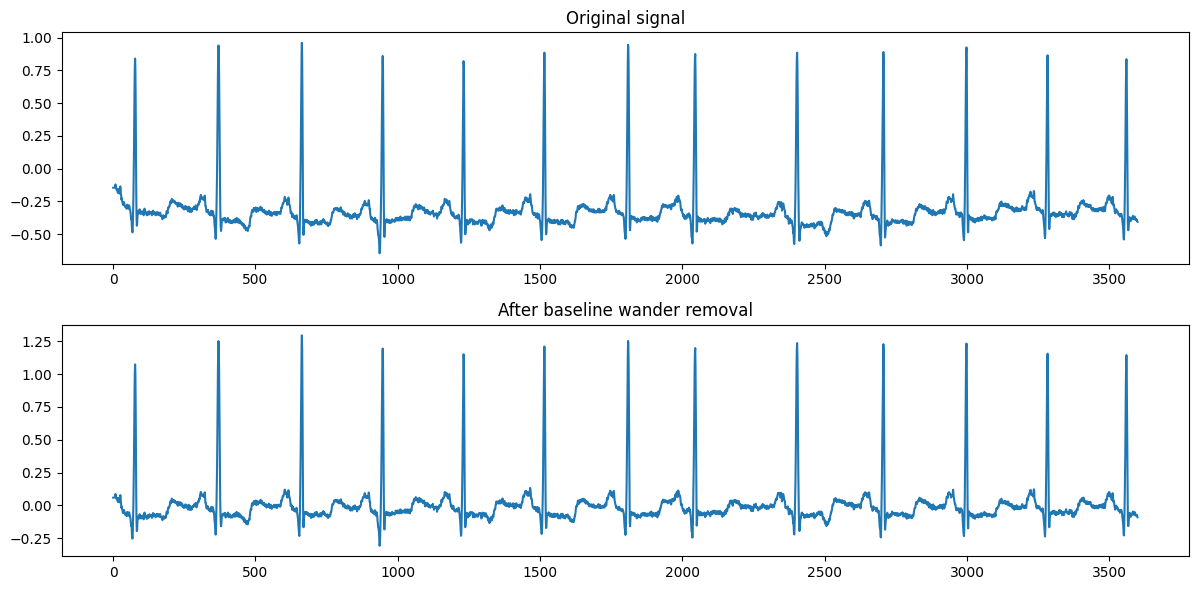

In [7]:
from scipy.signal import butter, filtfilt

def remove_baseline_wander(signal, fs, cutoff=0.5):
    # Butterworth high-pass filter
    nyquist = fs / 2
    normalized_cutoff = cutoff / nyquist
    b, a = butter(2, normalized_cutoff, btype='high')
    return filtfilt(b, a, signal)

fs = 360
ecg_filtered = remove_baseline_wander(signal, fs)

# plot before and after
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(signal[:10*fs])
axes[0].set_title('Original signal')
axes[1].plot(ecg_filtered[:10*fs])
axes[1].set_title('After baseline wander removal')
plt.tight_layout()
plt.show()

In [8]:
from scipy.signal import iirnotch, filtfilt

def apply_notch_filter(signal, fs=360, freq=60.0, quality_factor=30.0):
    """
    Notch filter to remove powerline interference.
    
    freq: target frequency to eliminate (60 Hz in North America)
    quality_factor: Q = freq / bandwidth. Higher Q = narrower notch.
    Q=30 → bandwidth of 2 Hz, aggressive enough to kill 60 Hz hum
    without touching neighboring cardiac content.
    """
    b, a = iirnotch(freq, quality_factor, fs)
    return filtfilt(b, a, signal)

# Apply to your filtered signal (post high-pass)
ecg_notched = apply_notch_filter(ecg_filtered, freq=60.0)
ecg_notched = apply_notch_filter(ecg_notched, freq=120.0)

In [9]:
def apply_lowpass_filter(signal, fs=360, cutoff=40.0, order=2):
    nyquist = fs / 2
    normalized_cutoff = cutoff / nyquist
    b, a = butter(order, normalized_cutoff, btype='low')
    return filtfilt(b, a, signal)

ecg_clean = apply_lowpass_filter(ecg_notched)

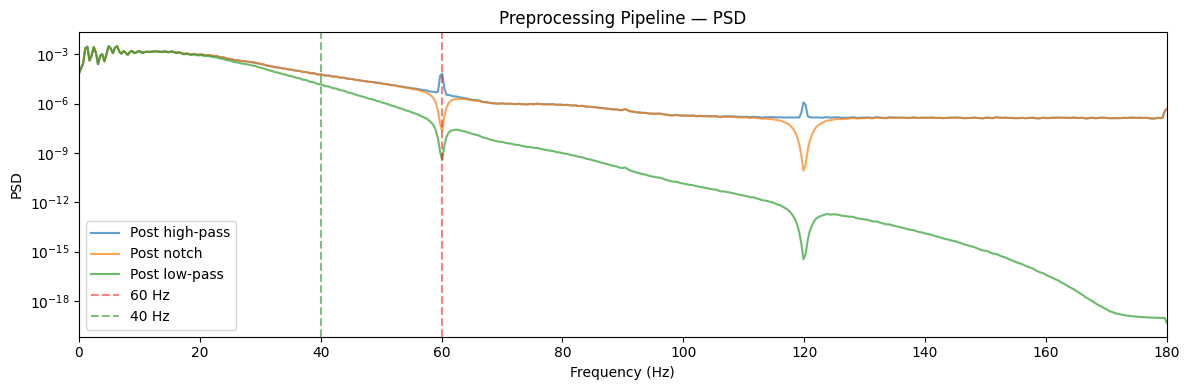

In [10]:
from scipy.signal import welch
import matplotlib.pyplot as plt

f1, psd1 = welch(ecg_filtered, fs=360, nperseg=1024)
f2, psd2 = welch(ecg_notched, fs=360, nperseg=1024)
f3, psd3 = welch(ecg_clean, fs=360, nperseg=1024)

plt.figure(figsize=(12, 4))
plt.semilogy(f1, psd1, label='Post high-pass', alpha=0.7)
plt.semilogy(f2, psd2, label='Post notch', alpha=0.7)
plt.semilogy(f3, psd3, label='Post low-pass', alpha=0.7)
plt.axvline(60, color='red', linestyle='--', alpha=0.5, label='60 Hz')
plt.axvline(40, color='green', linestyle='--', alpha=0.5, label='40 Hz')
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD')
plt.legend()
plt.title('Preprocessing Pipeline — PSD')
plt.xlim(0, 180)
plt.tight_layout()
plt.show()

In [11]:
def bandpass_filter(signal, fs=360, lowcut=5.0, highcut=15.0, order=1):
    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

pt_bandpassed = bandpass_filter(ecg_clean)

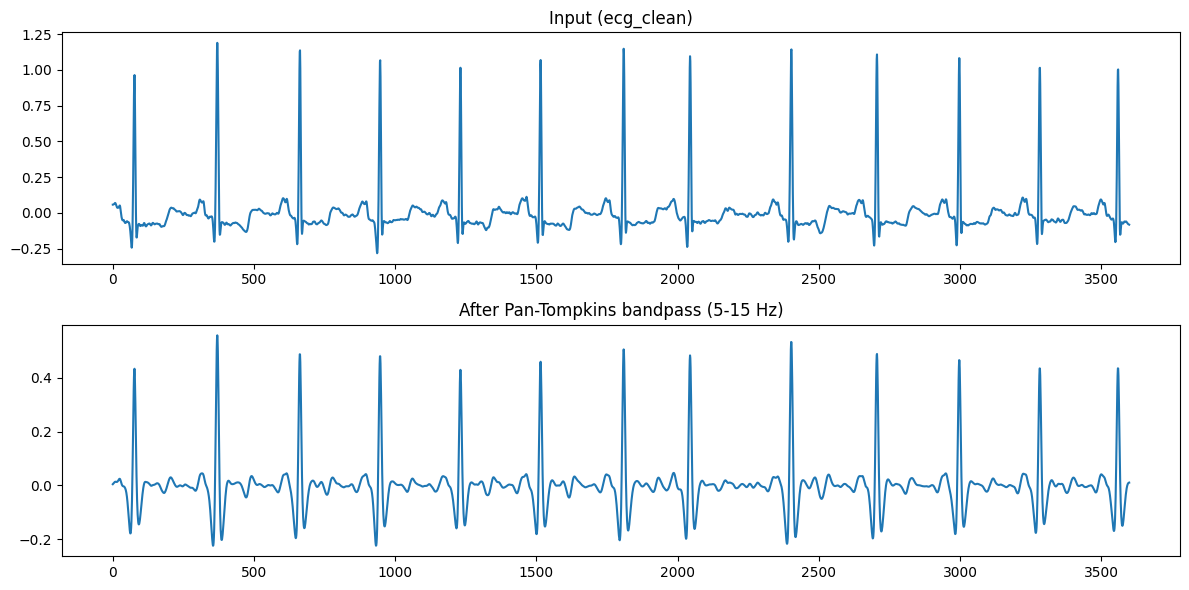

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(ecg_clean[:10*fs])
axes[0].set_title('Input (ecg_clean)')
axes[1].plot(pt_bandpassed[:10*fs])
axes[1].set_title('After Pan-Tompkins bandpass (5-15 Hz)')
plt.tight_layout()
plt.show()

In [13]:
def differentiate(signal, fs=360):
    diff = np.zeros_like(signal)
    for i in range(2, len(signal) - 2):
        diff[i] = (1/(12/fs)) * (-signal[i-2] - 8*signal[i-1] + 8*signal[i+1] + signal[i+2])
    return diff

pt_differentiated = differentiate(pt_bandpassed)

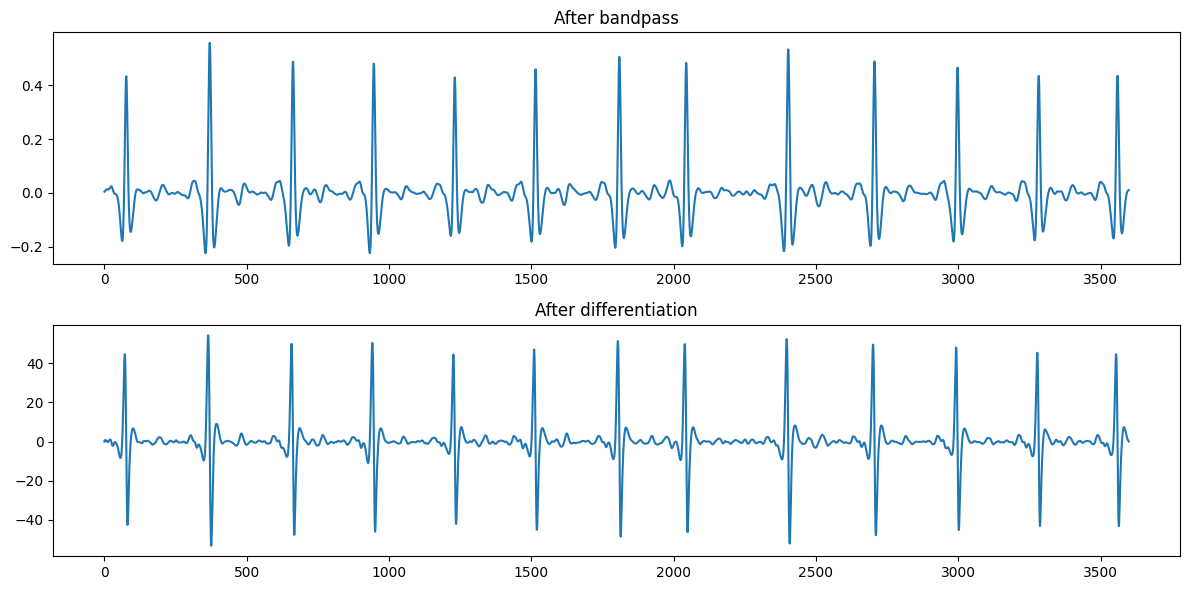

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(pt_bandpassed[:10*fs])
axes[0].set_title('After bandpass')
axes[1].plot(pt_differentiated[:10*fs])
axes[1].set_title('After differentiation')
plt.tight_layout()
plt.show()

In [15]:
def square(signal):
    return signal ** 2

pt_squared = square(pt_differentiated)

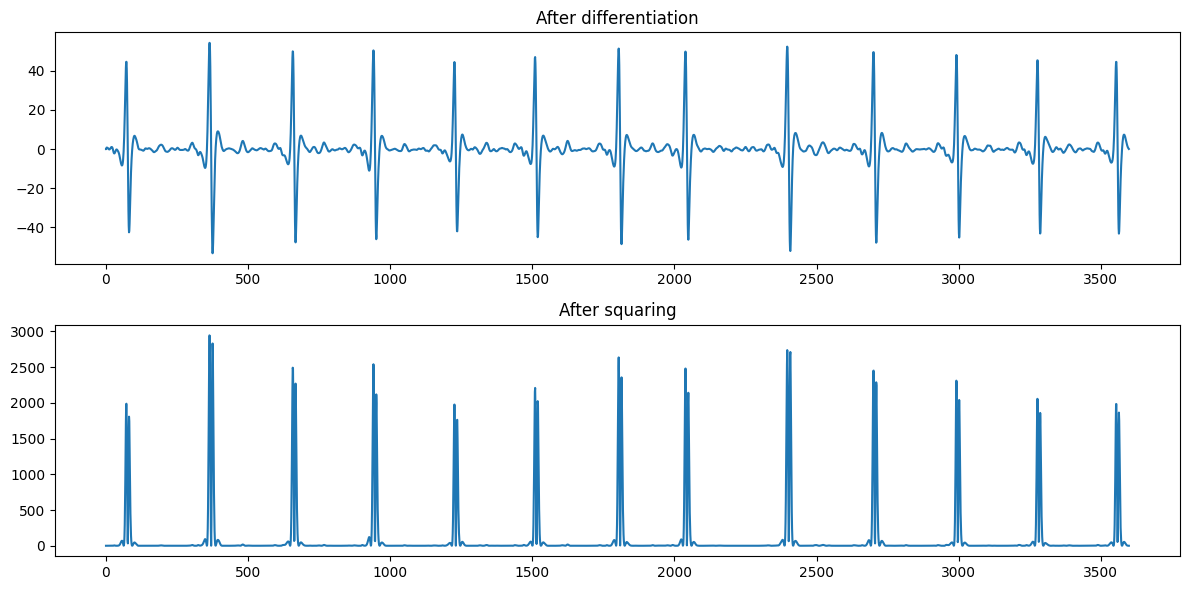

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(pt_differentiated[:10*fs])
axes[0].set_title('After differentiation')
axes[1].plot(pt_squared[:10*fs])
axes[1].set_title('After squaring')
plt.tight_layout()
plt.show()

In [17]:
def moving_window_integration(signal, fs=360, window_ms=150):
    window_size = int(window_ms * fs / 1000)
    integrated = np.convolve(signal, np.ones(window_size) / window_size, mode='same')
    return integrated

pt_integrated = moving_window_integration(pt_squared)

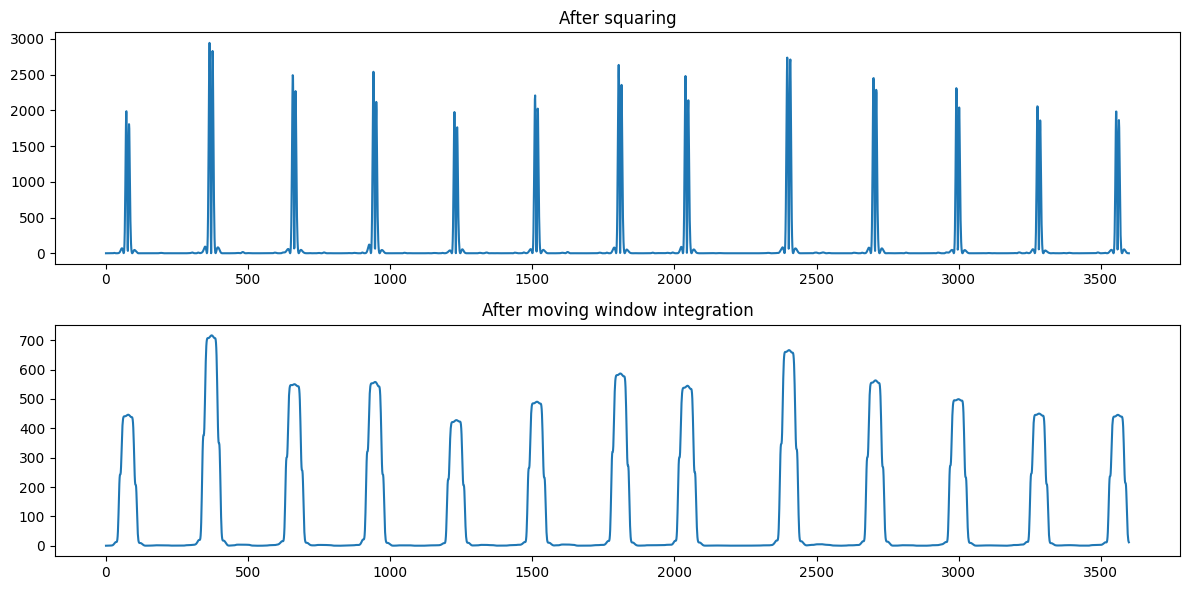

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(pt_squared[:10*fs])
axes[0].set_title('After squaring')
axes[1].plot(pt_integrated[:10*fs])
axes[1].set_title('After moving window integration')
plt.tight_layout()
plt.show()

In [19]:
def adaptive_threshold(signal, fs=360, min_distance_ms=200):
    min_distance = int(min_distance_ms * fs / 1000)
    
    # Find all local peaks first
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(signal, distance=min_distance)
    
    # Initialize estimates from first 2 seconds
    init_peaks = peaks[peaks < 2 * fs]
    SPKI = np.mean(signal[init_peaks]) if len(init_peaks) > 0 else np.max(signal) * 0.25
    NPKI = SPKI * 0.5
    
    qrs_peaks = []
    
    for peak in peaks:
        threshold = 0.25 * SPKI + 0.75 * NPKI
        
        if signal[peak] >= threshold:
            qrs_peaks.append(peak)
            SPKI = 0.125 * signal[peak] + 0.875 * SPKI  # running average
        else:
            NPKI = 0.125 * signal[peak] + 0.875 * NPKI
    
    return np.array(qrs_peaks)

r_peaks = adaptive_threshold(pt_integrated)

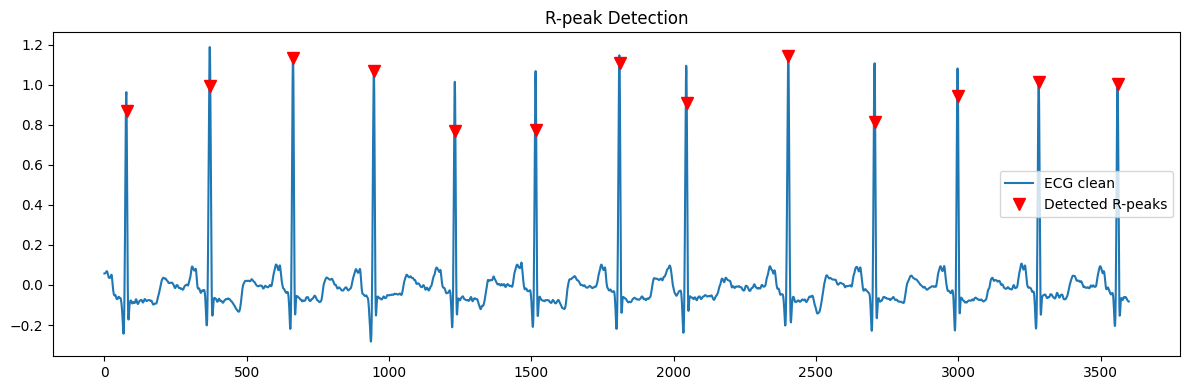

In [20]:
plt.figure(figsize=(12, 4))
plt.plot(ecg_clean[:10*fs], label='ECG clean')
plt.plot(r_peaks[r_peaks < 10*fs], 
         ecg_clean[r_peaks[r_peaks < 10*fs]], 
         'rv', markersize=8, label='Detected R-peaks')
plt.title('R-peak Detection')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
def refine_peaks(r_peaks, signal, search_window_ms=50, fs=360):
    search_window = int(search_window_ms * fs / 1000)
    refined = []
    for peak in r_peaks:
        start = max(0, peak - search_window)
        end = min(len(signal), peak + search_window)
        local_max = start + np.argmax(signal[start:end])
        refined.append(local_max)
    return np.array(refined)

r_peaks_refined = refine_peaks(r_peaks, ecg_clean)

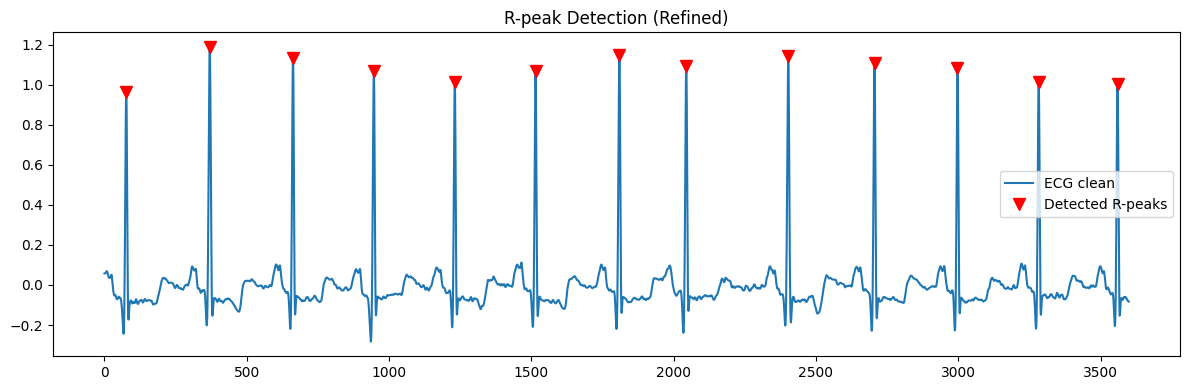

In [22]:
plt.figure(figsize=(12, 4))
plt.plot(ecg_clean[:10*fs], label='ECG clean')
plt.plot(r_peaks_refined[r_peaks_refined < 10*fs], 
         ecg_clean[r_peaks_refined[r_peaks_refined < 10*fs]], 
         'rv', markersize=8, label='Detected R-peaks')
plt.title('R-peak Detection (Refined)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
def segment_beats(signal, r_peaks, window=180):
    beats = []
    valid_peaks = []
    
    for peak in r_peaks:
        start = peak - window
        end = peak + window
        
        # Skip beats too close to signal boundaries
        if start < 0 or end > len(signal):
            continue
            
        beats.append(signal[start:end])
        valid_peaks.append(peak)
    
    return np.array(beats), np.array(valid_peaks)

beats, valid_peaks = segment_beats(ecg_clean, r_peaks_refined)
print(f"Extracted {len(beats)} beats, each of shape {beats[0].shape}")

Extracted 2271 beats, each of shape (360,)


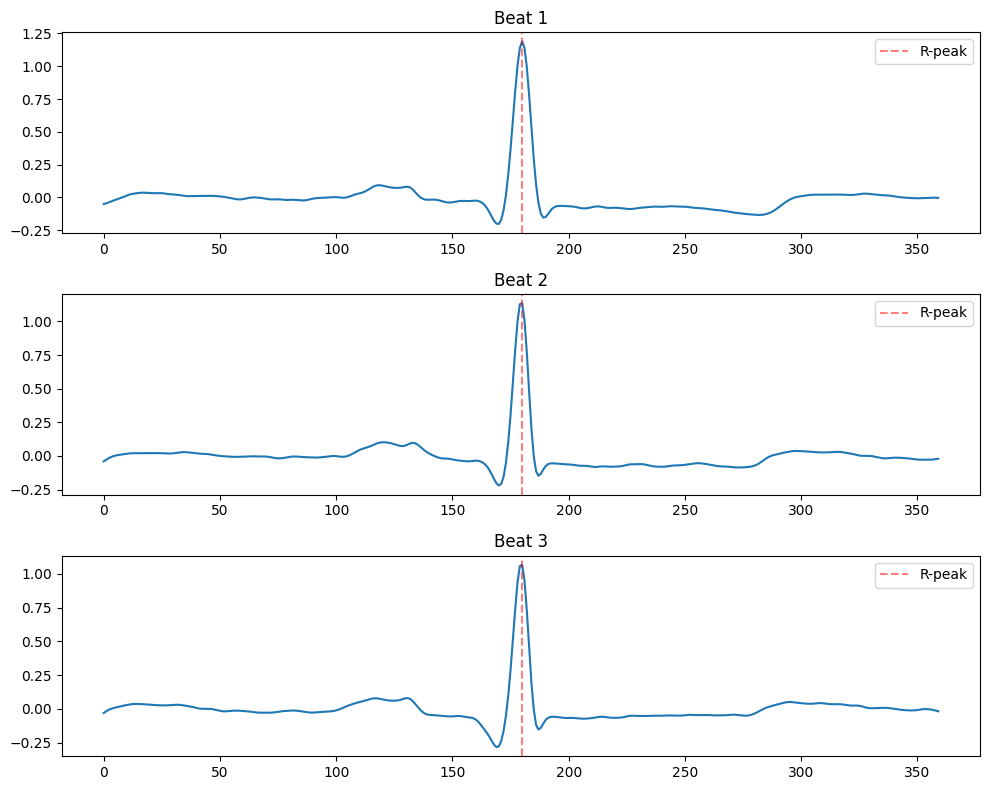

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
for i, ax in enumerate(axes):
    ax.plot(beats[i])
    ax.axvline(180, color='red', linestyle='--', alpha=0.5, label='R-peak')
    ax.set_title(f'Beat {i+1}')
    ax.legend()
plt.tight_layout()
plt.show()

In [25]:
annotation = wfdb.rdann('data/mitdb/100', 'atr')

def label_beats(valid_peaks, annotation, tolerance=36):
    """Match each detected peak to nearest annotation within tolerance (36 samples = 100ms)"""
    labels = []
    for peak in valid_peaks:
        distances = np.abs(annotation.sample - peak)
        nearest_idx = np.argmin(distances)
        if distances[nearest_idx] <= tolerance:
            labels.append(annotation.symbol[nearest_idx])
        else:
            labels.append('?')  # no annotation found nearby
    return labels

labels = label_beats(valid_peaks, annotation)
print(f"Label distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

Label distribution: {np.str_('A'): np.int64(33), np.str_('N'): np.int64(2237), np.str_('V'): np.int64(1)}


In [26]:
print(f"Unmatched beats: {labels.count('?')}")

Unmatched beats: 0


In [27]:
AAMI_MAP = {
    # Normal
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    # Supraventricular ectopic
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    # Ventricular ectopic
    'V': 'V', 'E': 'V',
    # Fusion
    'F': 'F',
    # Unknown/paced
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

def map_to_aami(labels):
    return [AAMI_MAP.get(l, 'Q') for l in labels]

aami_labels = map_to_aami(labels)
print(f"AAMI distribution: {dict(zip(*np.unique(aami_labels, return_counts=True)))}")

AAMI distribution: {np.str_('N'): np.int64(2237), np.str_('S'): np.int64(33), np.str_('V'): np.int64(1)}


In [28]:
import numpy as np

def extract_rr_features(valid_peaks, fs=360, local_window=10):
    """
    Extract RR interval features for each beat.
    
    Parameters
    ----------
    valid_peaks : np.ndarray
        Sample indices of confirmed R-peaks.
    fs : int
        Sampling frequency in Hz.
    local_window : int
        Number of surrounding beats for local mean RR calculation.
    
    Returns
    -------
    rr_features : np.ndarray, shape (n_beats, 4)
        Columns: [pre_rr, post_rr, ratio, local_mean_rr]
    """
    n_beats = len(valid_peaks)
    rr_features = np.zeros((n_beats, 4))
    
    # RR intervals in seconds between consecutive peaks
    rr_intervals = np.diff(valid_peaks) / fs  # shape: (n_beats - 1,)
    
    for i in range(n_beats):
        # pre_rr: interval before this beat
        if i == 0:
            pre_rr = rr_intervals[0]  # impute with first available
        else:
            pre_rr = rr_intervals[i - 1]
        
        # post_rr: interval after this beat
        if i == n_beats - 1:
            post_rr = rr_intervals[-1]  # impute with last available
        else:
            post_rr = rr_intervals[i]
        
        # ratio
        ratio = pre_rr / post_rr
        
        # local_mean_rr: mean of surrounding window of RR intervals
        half = local_window // 2
        start = max(0, i - half)
        end = min(len(rr_intervals), i + half)
        local_mean_rr = np.mean(rr_intervals[start:end])
        
        rr_features[i] = [pre_rr, post_rr, ratio, local_mean_rr]
    
    return rr_features


# Run it
rr_features = extract_rr_features(valid_peaks, fs=360, local_window=10)

print(f"RR features shape: {rr_features.shape}")
print(f"\nFeature means:")
print(f"  pre_rr:        {rr_features[:, 0].mean():.4f}s")
print(f"  post_rr:       {rr_features[:, 1].mean():.4f}s")
print(f"  ratio:         {rr_features[:, 2].mean():.4f}")
print(f"  local_mean_rr: {rr_features[:, 3].mean():.4f}s")

RR features shape: (2271, 4)

Feature means:
  pre_rr:        0.7946s
  post_rr:       0.7946s
  ratio:         1.0035
  local_mean_rr: 0.7946s


In [29]:
import pywt
import numpy as np

def extract_wavelet_features(beats, wavelet='db4', level=5):
    """
    Extract wavelet features from beat waveforms.
    
    Parameters
    ----------
    beats : np.ndarray, shape (n_beats, 360)
        Segmented beat windows.
    wavelet : str
        Mother wavelet to use.
    level : int
        Number of decomposition levels.
    
    Returns
    -------
    wavelet_features : np.ndarray, shape (n_beats, (level+1) * 3)
        Columns: [energy, mean, std] for each sub-band (D1..D5, A5)
    """
    n_beats = beats.shape[0]
    n_features = (level + 1) * 3  # 3 stats per sub-band, +1 for final approximation
    wavelet_features = np.zeros((n_beats, n_features))
    
    for i, beat in enumerate(beats):
        # Decompose — returns [cA5, cD5, cD4, cD3, cD2, cD1]
        coeffs = pywt.wavedec(beat, wavelet=wavelet, level=level)
        
        feature_row = []
        for coeff in coeffs:
            energy = np.sum(coeff ** 2)
            mean   = np.mean(coeff)
            std    = np.std(coeff)
            feature_row.extend([energy, mean, std])
        
        wavelet_features[i] = feature_row
    
    return wavelet_features


# Run it
wavelet_features = extract_wavelet_features(beats, wavelet='db4', level=5)

print(f"Wavelet features shape: {wavelet_features.shape}")
print(f"\nSub-band energy means (A5 first, then D5..D1):")
sub_bands = ['A5', 'D5', 'D4', 'D3', 'D2', 'D1']
for idx, name in enumerate(sub_bands):
    energy_mean = wavelet_features[:, idx * 3].mean()
    print(f"  {name}: {energy_mean:.4f}")

Wavelet features shape: (2271, 18)

Sub-band energy means (A5 first, then D5..D1):
  A5: 2.7487
  D5: 1.7786
  D4: 3.0795
  D3: 2.1918
  D2: 0.0595
  D1: 0.0006


In [30]:
features = np.hstack([rr_features, wavelet_features])
print(f"Combined features shape: {features.shape}")

Combined features shape: (2271, 22)


In [31]:
LABEL_MAP = {'N': 0, 'S': 1, 'V': 2, 'F': 3, 'Q': 4}
y = np.array([LABEL_MAP[l] for l in aami_labels])
print(f"Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

Label distribution: {np.int64(0): np.int64(2237), np.int64(1): np.int64(33), np.int64(2): np.int64(1)}


In [32]:
def normalize_records(signal):
    """
    Normalize record.
    
    Parameters
    ----------
    signal : Full record signal.
    
    Returns
    -------
    normalized_signal : The same signal after z-score normalization.
    """
    mean = np.mean(signal)
    std = np.std(signal)

    if std == 0:
        print("Error, std is 0.")
        return signal
    
    normalized_signal = (signal-mean)/std
    
    return normalized_signal


In [33]:
def per_record_processing():
    """
    Processes each record.
    
    Parameters
    ----------
    
    Returns
    -------
    normalized_signal : The same signal after z-score normalization.
    """
    
    # Record list
    records = wfdb.get_record_list('mitdb')

    all_rr_features = []
    all_wavelet_features = []
    all_labels = []
    all_patient_ids = []

    AAMI_MAP = {
        # Normal
        'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
        # Supraventricular ectopic
        'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
        # Ventricular ectopic
        'V': 'V', 'E': 'V',
        # Fusion
        'F': 'F',
        # Unknown/paced
        '/': 'Q', 'f': 'Q', 'Q': 'Q'
    }

    for i in records:
        # Step 1: Load record data
        record = wfdb.rdrecord(f'data/mitdb/{i}')
        signal = record.p_signal[:, 0]  # channel 0

        # Step 2: Preprocess and normalize
        fs = 360
        ecg_filtered = remove_baseline_wander(signal, fs)
        ecg_notched = apply_notch_filter(ecg_filtered, freq=60.0)
        ecg_notched = apply_notch_filter(ecg_notched, freq=120.0)
        ecg_clean = apply_lowpass_filter(ecg_notched)
        ecg_normalized = normalize_records(ecg_clean)

        # Step 3: Pan-Tompkins algorithm
        pt_bandpassed = bandpass_filter(ecg_normalized)
        pt_differentiated = differentiate(pt_bandpassed)
        pt_squared = square(pt_differentiated)
        pt_integrated = moving_window_integration(pt_squared)
        r_peaks = adaptive_threshold(pt_integrated)
        r_peaks_refined = refine_peaks(r_peaks, ecg_clean)

        # Step 4: Beat segmentation
        beats, valid_peaks = segment_beats(ecg_normalized, r_peaks_refined)

        # Step 5: Label beats
        annotation = wfdb.rdann(f'data/mitdb/{i}', 'atr')
        labels = label_beats(valid_peaks, annotation)
        aami_labels = map_to_aami(labels)
        
        # Step 6: Feature extraction
        rr_features = extract_rr_features(valid_peaks, fs=360, local_window=10)
        wavelet_features = extract_wavelet_features(beats, wavelet='db4', level=5)

        all_rr_features.append(rr_features)
        all_wavelet_features.append(wavelet_features)
        all_labels.append(aami_labels)
        all_patient_ids.append([i] * len(aami_labels))


    X_rr = np.vstack(all_rr_features)
    X_wavelet = np.vstack(all_wavelet_features)
    X_labels = np.concatenate(all_labels)
    X_patient_ids = np.concatenate(all_patient_ids)

    return X_rr, X_wavelet, X_labels, X_patient_ids
        

In [34]:
X_rr, X_wavelet, X_labels, X_patient_ids = per_record_processing()

print(np.shape(X_rr))
print(np.shape(X_wavelet))
print(np.shape(X_labels))
print(np.shape(X_patient_ids))
np.unique(X_patient_ids)

(105604, 4)
(105604, 18)
(105604,)
(105604,)


array(['100', '101', '102', '103', '104', '105', '106', '107', '108',
       '109', '111', '112', '113', '114', '115', '116', '117', '118',
       '119', '121', '122', '123', '124', '200', '201', '202', '203',
       '205', '207', '208', '209', '210', '212', '213', '214', '215',
       '217', '219', '220', '221', '222', '223', '228', '230', '231',
       '232', '233', '234'], dtype='<U3')

In [35]:
X_features = np.concatenate([X_rr, X_wavelet], axis=1)

print(np.shape(X_features))

(105604, 22)


In [36]:
X_mask = X_labels != 'Q'
X_labels_filtered = X_labels[X_mask]
X_features_filtered = X_features[X_mask]
X_patient_ids_filtered = X_patient_ids[X_mask]

In [37]:
print(np.shape(X_features_filtered))
print(np.shape(X_labels_filtered))
print(np.shape(X_patient_ids_filtered))
np.unique(X_labels_filtered)

(98384, 22)
(98384,)
(98384,)


array(['F', 'N', 'S', 'V'], dtype='<U1')

In [49]:
np.random.seed(42)

test_ids = np.random.choice(np.unique(X_patient_ids_filtered), size=(10), replace=False, p=None)
print(test_ids)

['205' '222' '203' '230' '201' '219' '113' '121' '104' '202']


In [50]:
mask = np.isin(np.unique(X_patient_ids_filtered), test_ids, invert=True)
print(mask)

[ True  True  True  True False  True  True  True  True  True  True  True
 False  True  True  True  True  True  True False  True  True  True  True
 False False False False  True  True  True  True  True  True  True  True
  True False  True  True False  True  True False  True  True  True  True]


In [51]:
train_ids = np.unique(X_patient_ids_filtered)[mask]
print(train_ids)

['100' '101' '102' '103' '105' '106' '107' '108' '109' '111' '112' '114'
 '115' '116' '117' '118' '119' '122' '123' '124' '200' '207' '208' '209'
 '210' '212' '213' '214' '215' '217' '220' '221' '223' '228' '231' '232'
 '233' '234']


In [52]:
print(np.size(train_ids))
print(np.size(test_ids))

38
10


In [61]:
train_mask = np.isin(X_patient_ids_filtered, train_ids)
X_train = X_features_filtered[train_mask]
Y_train = X_labels_filtered[train_mask]

test_mask = ~train_mask
X_test = X_features_filtered[test_mask]
Y_test = X_labels_filtered[test_mask]

print(np.shape(X_train))
print(np.shape(Y_train))
print(np.shape(X_test))
print(np.shape(Y_test))

(78299, 22)
(78299,)
(20085, 22)
(20085,)


In [64]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [67]:
predictions = rf.predict(X_test)
print(predictions)

['N' 'N' 'N' ... 'N' 'N' 'N']


In [71]:
from sklearn.metrics import classification_report

classification_report(Y_test, predictions)

'              precision    recall  f1-score   support\n\n           F       0.00      0.00      0.00        14\n           N       0.98      0.93      0.96     18971\n           S       0.27      0.40      0.32       338\n           V       0.32      0.65      0.43       762\n\n    accuracy                           0.91     20085\n   macro avg       0.39      0.50      0.43     20085\nweighted avg       0.94      0.91      0.93     20085\n'

In [72]:
print(classification_report(Y_test, predictions)) 

              precision    recall  f1-score   support

           F       0.00      0.00      0.00        14
           N       0.98      0.93      0.96     18971
           S       0.27      0.40      0.32       338
           V       0.32      0.65      0.43       762

    accuracy                           0.91     20085
   macro avg       0.39      0.50      0.43     20085
weighted avg       0.94      0.91      0.93     20085



In [75]:
from sklearn.model_selection import GroupKFold

groups_kfold = GroupKFold()
print(groups_kfold)

GroupKFold(n_splits=5, random_state=None, shuffle=False)


In [80]:
from sklearn.metrics import f1_score
from imblearn.over_sampling import SMOTE

f1_scores = []

for train_idx, test_idx in groups_kfold.split(X_features_filtered, X_labels_filtered, X_patient_ids_filtered):
    # slice X_features, X_labels_filtered using train_idx and test_idx
    X_train = X_features_filtered[train_idx]
    Y_train = X_labels_filtered[train_idx]
    X_test = X_features_filtered[test_idx]
    Y_test = X_labels_filtered[test_idx]

    # SMOTE
    label_count = np.unique(Y_train, return_counts=True)
    N_count = label_count[1][1]
    
    sample_count = int(N_count * 0.1)

    sm_key = {}
    if(sample_count > label_count[1][2]):
        sm_key['S'] = sample_count

    if(sample_count > label_count[1][3]):
        sm_key['V'] = sample_count

    if(sm_key):
        sm = SMOTE(random_state=42, sampling_strategy=sm_key)
        X_res, y_res = sm.fit_resample(X_train, Y_train)
    
        # train RF
        rf = RandomForestClassifier(random_state=42, class_weight='balanced')
        rf.fit(X_res, y_res)
    else:
        rf = RandomForestClassifier(random_state=42, class_weight='balanced')
        rf.fit(X_train, Y_train)
    
    # predict
    predictions = rf.predict(X_test)
    
    # compute macro F1
    classification_report(Y_test, predictions)

    print(classification_report(Y_test, predictions))
    f1_scores.append(f1_score(Y_test, predictions, average='macro'))


f1_scores_mean = np.mean(f1_scores)
f1_scores_std = np.std(f1_scores)

print(f1_scores_mean)
print(f1_scores_std)

              precision    recall  f1-score   support

           F       0.00      0.00      0.00         7
           N       0.90      1.00      0.95     16623
           S       0.08      0.01      0.01      1493
           V       0.94      0.60      0.73      1087

    accuracy                           0.90     19210
   macro avg       0.48      0.40      0.42     19210
weighted avg       0.84      0.90      0.86     19210

              precision    recall  f1-score   support

           F       0.02      0.00      0.00       369
           N       0.95      0.97      0.96     17744
           S       0.20      0.05      0.08       195
           V       0.44      0.52      0.48       892

    accuracy                           0.92     19200
   macro avg       0.40      0.39      0.38     19200
weighted avg       0.90      0.92      0.91     19200

              precision    recall  f1-score   support

           F       0.00      0.00      0.00        12
           N       0.